# Implied Volatility Surface Prediction

**Goal:** fill the missing implied-volatility values in a 975 (timestamp) x 28 (strike)
grid of NIFTY 27-JAN-2026 options, minimising MSE against the hidden truth.

## Approach in one paragraph
The data contains **two regimes** that need different treatment:
1. **Normal days** — a smooth, slowly-evolving skew. Each strike is highly correlated
   with the others, so we impute each missing strike as a **learned linear function of
   the other strikes at the same timestamp** (a regularised linear "mapping" model).
2. **The expiry day (0DTE)** — implied vol *explodes* as time-to-expiry -> 0, forming a
   sharp **V** whose wings are essentially linear in log-moneyness. Here a linear map
   cannot extrapolate the exploding wings, so we split the expiry smile:
   * **interior / at-the-money** -> linear map (fit on expiry rows only),
   * **wings** -> straight-line extrapolation along the (linear) wing.

**No look-ahead:** every missing value is predicted only from the **same timestamp's**
other strikes. The linear maps are fit transductively on the historical panel (standard
imputation); no future timestamp is used as a feature for any prediction.

Everything is deterministic (`random_state=0`) and this notebook regenerates the exact
submitted CSV.

## 1. Load & parse

In [2]:
import re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
warnings.filterwarnings("ignore")

df = pd.read_csv("/kaggle/input/competitions/finclub-open-project-26/dataset.csv")
option_cols = [c for c in df.columns if c.endswith(("CE", "PE"))]
# strike = the 5 digits before CE/PE.  NB: a greedy \d+ would swallow the '26' of
# the expiry 'JAN26' and mis-parse the strike, so we anchor to exactly 5 digits.
strike = lambda c: int(re.search(r"(\d{5})(CE|PE)$", c).group(1))
opt = sorted(option_cols, key=strike)                 # columns ordered by strike
K   = np.array([strike(c) for c in opt], float)
IV  = df[opt].to_numpy(float)                         # (975, 28) with NaNs
S   = df["underlying_price"].to_numpy(float)
M   = np.log(K[None, :] / S[:, None])                 # log-moneyness ln(K/S)

dt  = pd.to_datetime(df["datetime"], format="%d-%m-%Y %H:%M")
expiry_date = dt.dt.date.max()
is_exp = (dt.dt.date == expiry_date).to_numpy()       # expiry-day rows
TTE = (pd.Timestamp(str(expiry_date) + " 15:30") - dt).dt.total_seconds().to_numpy() / 60.0  # min to expiry

print(f"grid {IV.shape} | missing {np.isnan(IV).sum()} ({np.isnan(IV).mean():.1%}) "
      f"| expiry rows {is_exp.sum()} (date {expiry_date})")

grid (975, 28) | missing 5460 (20.0%) | expiry rows 75 (date 2026-01-27)


## 2. Data : understanding why two regimes

The error is dominated by a small set of "high IV" cells. These are cells with high values where IV blows up as T -> 0.

In [3]:
high = IV > 0.30
hi_rows = np.where(high.any(axis=1))[0]
print("cells with IV>0.30 :", int(high.sum()))
print("...on the expiry day:", int(high[is_exp].sum()),
      f"({high[is_exp].sum()/high.sum():.1%})")
print("normal-day IV range :", f"{np.nanmin(IV[~is_exp]):.3f} – {np.nanmax(IV[~is_exp]):.3f}")
print("expiry-day IV range :", f"{np.nanmin(IV[is_exp]):.3f} – {np.nanmax(IV[is_exp]):.3f}")

cells with IV>0.30 : 1621
...on the expiry day: 1620 (99.9%)
normal-day IV range : 0.059 – 0.303
expiry-day IV range : 0.017 – 5.385


The expiry smile transitions from a rounded **U** early in the day to a sharp **V** with
near linear wings as expiry approaches, which is why the wings get a straight-line fit.

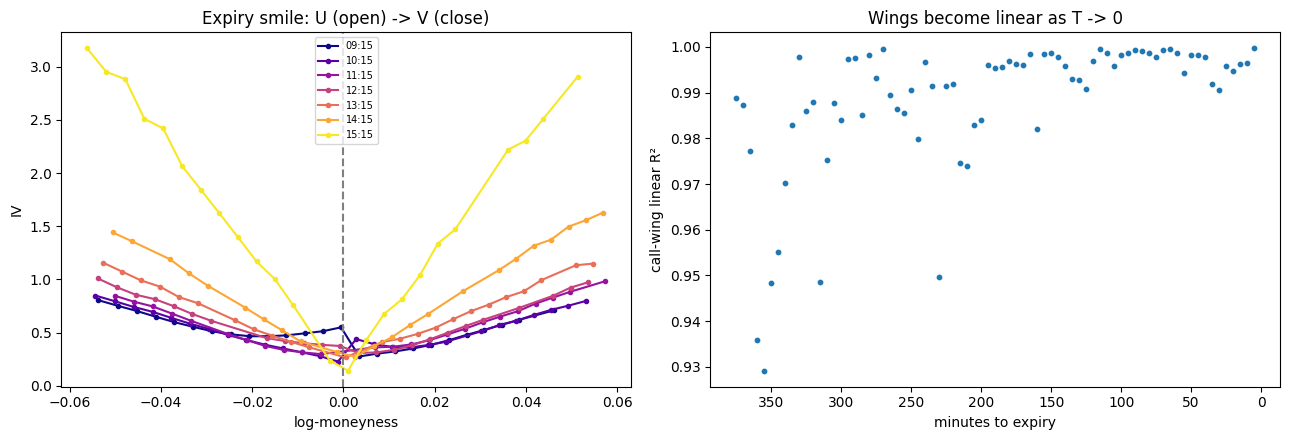

In [4]:
ed = np.where(is_exp)[0]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for r in ed[::12]:
    o = ~np.isnan(IV[r]); col = plt.cm.plasma(1 - TTE[r] / TTE[ed].max())
    ax[0].plot(M[r][o], IV[r][o], "-o", ms=3, color=col, label=f'{dt[r].strftime("%H:%M")}')
ax[0].set(xlabel="log-moneyness", ylabel="IV", title="Expiry smile: U (open) -> V (close)")
ax[0].axvline(0, ls="--", c="gray"); ax[0].legend(fontsize=7)
# wing linearity through the day
lin = []
for t in ed:
    o = ~np.isnan(IV[t]) & (M[t] > 0.005)
    if o.sum() >= 4:
        x, y = np.abs(M[t][o]), IV[t][o]; b = np.polyfit(x, y, 1)
        lin.append((TTE[t], 1 - np.sum((y - np.polyval(b, x))**2) / np.sum((y - y.mean())**2)))
lin = np.array(lin)
ax[1].scatter(lin[:, 0], lin[:, 1], s=10); ax[1].invert_xaxis()
ax[1].set(xlabel="minutes to expiry", ylabel="call-wing linear R²",
          title="Wings become linear as T -> 0")
plt.tight_layout(); plt.show()

## 3. Model

Each missing cell is routed to the method that is best in its region:

| region | method |
|---|---|
| **normal day** | linear-map imputation (fit on normal rows) |
| **expiry, at-the-money** (`\|m\| <= boundary`) | linear map imputation (fit on **expiry rows only**) |
| **expiry, wings** (`\|m\| > boundary`) | straight line extrapolation along the wing |

The wing/ATM **boundary is time adaptive**: it tightens to 0.02 near expiry (sharp V, the
linear wing reaches close to ATM) and widens to 0.035 early (rounded U).

Fitting the expiry imputer on **expiry rows only** matters: pooling it with the 900 normal
rows lets the normal regime contaminate the 75 expiry-specific strike relationships.

In [5]:
WING_K = 5

def make_imputer(order):
    return IterativeImputer(estimator=BayesianRidge(), max_iter=25, tol=1e-3,
                            imputation_order=order, random_state=0)

def linear_wing(row, m, mj, k=WING_K):
    # straight line through the k nearest observed quotes on the cell's side
    o = np.where(~np.isnan(row))[0]
    same = o[(m[o] < 0)] if mj < 0 else o[(m[o] >= 0)]
    if len(same) < 2:
        same = o
    x, y = m[same], row[same]
    idx = np.argsort(np.abs(x - mj))[:k]
    if len(idx) < 2:
        return np.nan
    return max(np.polyval(np.polyfit(x[idx], y[idx], 1), mj), 0.01)

def cubic_fallback(row, m, mj):
    # self-contained fallback (only for a degenerate expiry wing with <2 same-side quotes)
    o = np.where(~np.isnan(row))[0]
    if len(o) < 4:
        return float(np.nanmean(row)) if o.size else 0.12
    xs = m[o]; r = np.argsort(xs); xs = xs[r]; ys = row[o][r]
    xs, i = np.unique(xs, return_index=True); ys = ys[i]
    return float(CubicSpline(xs, ys, bc_type="natural")(mj))

def fill_surface(IV, M, is_exp, TTE):
    out = IV.copy(); miss = np.isnan(IV)

    # (a) NORMAL blanks -> linear map fit on normal rows
    Zn = make_imputer("roman").fit_transform(IV[~is_exp])
    nb = miss[~is_exp]; blk = out[~is_exp]; blk[nb] = Zn[nb]; out[~is_exp] = blk

    # (b) EXPIRY blanks -> linear map fit on EXPIRY ROWS ONLY (used for the ATM interior)
    eidx = np.where(is_exp)[0]
    Ze = make_imputer("ascending").fit_transform(IV[eidx])

    # (c) per expiry row: wings -> linear wing ; interior -> expiry linear map
    for r, t in enumerate(eidx):
        row, m = IV[t], M[t]
        nobs = (~np.isnan(row)).sum()
        boundary = 0.02 if TTE[t] < 100 else 0.035       # T-adaptive
        for j in np.where(np.isnan(row))[0]:
            if abs(m[j]) > boundary:                      # exploding wing
                p = linear_wing(row, m, m[j]) if nobs >= 4 else np.nan
                out[t, j] = p if not np.isnan(p) else cubic_fallback(row, m, m[j])
            else:                                         # interior / ATM
                out[t, j] = Ze[r, j]

    out = np.maximum(out, 0.01)
    assert not np.isnan(out).any()
    return out

## 4. Validation

We hide a random 15% of the **observed** cells, predict them, and measure MSE — reported
separately for the two regimes (the expiry regime is ~100x harder and dominates). This
masking respects the no-look-ahead rule (each prediction uses only same-timestamp strikes).

In [6]:
obs_idx = np.argwhere(~np.isnan(IV))
sn = nn = se = ne = 0
for fold in range(5):
    rng = np.random.default_rng(100 + fold)
    sel = rng.choice(len(obs_idx), int(0.15 * len(obs_idx)), replace=False)
    cells = obs_idx[sel]
    truth = IV[cells[:, 0], cells[:, 1]].copy()
    IVm = IV.copy(); IVm[cells[:, 0], cells[:, 1]] = np.nan
    pred = fill_surface(IVm, M, is_exp, TTE)[cells[:, 0], cells[:, 1]]
    e = (pred - truth) ** 2; ex = is_exp[cells[:, 0]]
    sn += e[~ex].sum(); nn += (~ex).sum(); se += e[ex].sum(); ne += ex.sum()
print(f"normal-cell MSE : {sn/nn:.3e}")
print(f"expiry-cell MSE : {se/ne:.3e}")
print(f"overall    MSE : {(sn+se)/(nn+ne):.3e}")

normal-cell MSE : 5.313e-06
expiry-cell MSE : 6.855e-04
overall    MSE : 5.888e-05


## 5. Generate the submission

In [10]:
filled = fill_surface(IV, M, is_exp, TTE)
submission = df.copy()
submission[opt] = filled
submission = submission[["datetime", "underlying_price"] + option_cols]   # original column order
submission.to_csv("submission1.csv", index=False)

# integrity checks
chk = pd.read_csv("/kaggle/input/competitions/finclub-open-project-26/dataset.csv")
obs_mask = chk[option_cols].notna().to_numpy()
assert list(chk.columns) == list(submission.columns)
assert not submission[option_cols].isna().any().any()
assert np.allclose(chk[option_cols].to_numpy()[obs_mask],
                   submission[option_cols].to_numpy()[obs_mask])   # observed cells unchanged
print("submission1.csv written:", submission.shape,
      "| observed cells preserved, no NaNs, original format")

submission1.csv written: (975, 30) | observed cells preserved, no NaNs, original format


In [12]:
import pandas as pd
import sys

ORIGINAL_DATASET_PATH = "/kaggle/input/competitions/finclub-open-project-26/dataset.csv" 

SEPARATOR = "||"

def generate_solution(filled_path: str, output_path: str = "solution.csv"):
    original = pd.read_csv(ORIGINAL_DATASET_PATH)
    filled   = pd.read_csv(filled_path)

    feature_cols = [c for c in original.columns if c != "datetime"]

    rows = []
    for col in feature_cols:
        was_missing = original[col].isna()

        for idx in original.index[was_missing]:
            dt  = original.loc[idx, "datetime"]
            uid = f"{dt}{SEPARATOR}{col}"
            val = filled.loc[idx, col]
            rows.append({"id": uid, "value": val})

    solution = pd.DataFrame(rows, columns=["id", "value"])
    solution = solution.sort_values("id").reset_index(drop=True)
    solution.to_csv(output_path, index=False)
    print(f"✅ Solution saved → {output_path}  ({len(solution)} rows)")

generate_solution("/kaggle/working/submission1.csv", "/kaggle/working/submission.csv") 

✅ Solution saved → /kaggle/working/submission.csv  (5460 rows)
